In [ ]:
"""
Module 3 Assignment - Chinese_Bakery dataset
AD
"""

In [1]:
import matplotlib.pyplot as plt
import numpy
import pandas

In [2]:
from mlxtend.frequent_patterns import (apriori, association_rules)
from mlxtend.preprocessing import TransactionEncoder

In [4]:
Imaginary_Store = pandas.read_csv('G:\\My Drive\\PROFESSIONAL\\MAS24\\Courses\\CSP571\\assignments\\Chinese_Bakery.csv')

Imaginary_Store['Item'].nunique() # unique sales items = 16

16

In [5]:
# Convert the Sale Receipt data to the Item List format
ListItem = Imaginary_Store.groupby(['Customer'])['Item'].apply(list).values.tolist()
ListItem

[['Egg Custard w/ Sweet Top Bun',
  'Plain Dinner Rolls',
  'Pineapple Sweet Top Bun',
  'Bean Paste Bun',
  'Ham & Egg Bun',
  'BBQ Pork Bun',
  'Coconut Twist Bun',
  'Egg Custard Tart',
  'Coffee',
  'Sponge Cake',
  'Steamed Rice Cake (Brown or White Sugar)'],
 ['Coconut Sweet Top Bun',
  'Egg Custard w/ Sweet Top Bun',
  'Coconut Cocktail Bun',
  'Bean Paste Bun',
  'Ham & Egg Bun',
  'BBQ Pork Bun',
  'Coconut Twist Bun',
  'Milk Tea (Hot)',
  'Sponge Cake',
  'Coconut Tart'],
 ['Egg Custard w/ Sweet Top Bun',
  'Plain Dinner Rolls',
  'Coconut Cocktail Bun',
  'Pineapple Sweet Top Bun',
  'Bean Paste Bun',
  'Egg Custard Tart',
  'Portuguese-Style Milk Egg Tart'],
 ['Plain Dinner Rolls',
  'Coconut Cocktail Bun',
  'Bean Paste Bun',
  'BBQ Pork Bun',
  'Egg Custard Tart',
  'Portuguese-Style Milk Egg Tart'],
 ['Egg Custard w/ Sweet Top Bun',
  'Plain Dinner Rolls',
  'Pineapple Sweet Top Bun',
  'Bean Paste Bun',
  'Ham & Egg Bun',
  'BBQ Pork Bun',
  'Coconut Twist Bun',
  'Por

In [21]:
# Convert the Item List format to the Item Indicator format
te = TransactionEncoder()
te_ary = te.fit(ListItem).transform(ListItem)
ItemIndicator = pandas.DataFrame(te_ary, columns=te.columns_)
nCustomer, nProduct = ItemIndicator.shape
ItemIndicator

,BBQ Pork Bun,Bean Paste Bun,Coconut Cocktail Bun,Coconut Sweet Top Bun,Coconut Tart,Coconut Twist Bun,Coffee,Egg Custard Tart,Egg Custard w/ Sweet Top Bun,Ham & Egg Bun,Milk Tea (Hot),Pineapple Sweet Top Bun,Plain Dinner Rolls,Portuguese-Style Milk Egg Tart,Sponge Cake,Steamed Rice Cake (Brown or White Sugar)
0,True,True,False,False,False,True,True,True,True,True,False,True,True,False,True,True
1,True,True,True,True,True,True,False,False,True,True,True,False,False,False,True,False
2,False,True,True,False,False,False,False,True,True,False,False,True,True,True,False,False
3,True,True,True,False,False,False,False,True,False,False,False,False,True,True,False,False
4,True,True,False,False,False,True,True,False,True,True,True,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,True,False,True,False,True,True,False,True,False,True,True,False,True,False,False,False
991,True,False,False,False,False,True,False,False,False,True,False,True,False,True,False,False
992,True,False,False,True,False,False,False,True,True,True,False,False,True,False,False,False
993,True,False,True,False,False,False,False,False,True,True,False,False,True,True,False,False


In [16]:
# Calculate the frequency table of number of customers per item
nCustomerPurchase = Imaginary_Store.groupby('Item').size() # how man y customers bought each item

freqTable = pandas.Series.sort_index(pandas.Series.value_counts(nCustomerPurchase))
print('Frequency of Number of Customers Purchase Item')
print(freqTable)

Frequency of Number of Customers Purchase Item
86     1
129    1
220    1
248    1
341    1
397    1
432    1
458    1
467    1
512    1
560    1
571    1
583    1
639    1
696    1
698    1
Name: count, dtype: int64


In [18]:
nCustomerPurchase
# freqTable

Item
BBQ Pork Bun                                698
Bean Paste Bun                              639
Coconut Cocktail Bun                        571
Coconut Sweet Top Bun                       467
Coconut Tart                                129
Coconut Twist Bun                           458
Coffee                                      341
Egg Custard Tart                            432
Egg Custard w/ Sweet Top Bun                512
Ham & Egg Bun                               696
Milk Tea (Hot)                              248
Pineapple Sweet Top Bun                     583
Plain Dinner Rolls                          560
Portuguese-Style Milk Egg Tart              397
Sponge Cake                                 220
Steamed Rice Cake (Brown or White Sugar)     86
dtype: int64

In [30]:
# Calculate the frequency table of number of items purchase
nItemPurchase = Imaginary_Store.groupby('Customer').size() # how much items per customer id - ek baar mai kitne khareede
freqTable = pandas.Series.sort_index(pandas.Series.value_counts(nItemPurchase))
# cumulative count count in freqTable 
freqTable['CumSum'] = freqTable.cumsum()
print('Frequency of Number of Items Purchase')
print(freqTable) # 2 items bought by 28 customers, 3 items bought by 26 customers etc

Frequency of Number of Items Purchase
2                                                        28
3                                                        26
4                                                        95
5                                                        95
6                                                       175
7                                                       136
8                                                       167
9                                                       108
10                                                      101
11                                                       44
12                                                       17
13                                                        2
14                                                        1
CumSum    2      28
3      54
4     149
5     244
6     ...
Name: count, dtype: object


In [20]:
nItemPurchase
freqTable

86     1
129    1
220    1
248    1
341    1
397    1
432    1
458    1
467    1
512    1
560    1
571    1
583    1
639    1
696    1
698    1
Name: count, dtype: int64

In [13]:
# Find the frequent itemsets
lowest_support = 10.0 / nCustomer
frequent_itemsets = apriori(ItemIndicator, min_support = lowest_support, max_len = 7, use_colnames = True)
print('Frequent Itemsets:')
print(frequent_itemsets)

Frequent Itemsets:
       support                                           itemsets
0     0.469347                                          (Bananas)
1     0.514573                                          (Bologna)
2     0.562814                                            (Bread)
3     0.573869                                             (Buns)
4     0.585930                                           (Butter)
...        ...                                                ...
8846  0.013065  (Milk, Cereal, Mayo, Cheese, Eggs, Mustard, Ch...
8847  0.013065  (Milk, Cereal, Mayo, Cheese, Mustard, Chips, H...
8848  0.010050  (Milk, Oranges, Cereal, Mayo, Cheese, Chips, H...
8849  0.012060  (Oranges, Cereal, Mayo, Cheese, Mustard, Chips...
8850  0.010050  (Milk, Oranges, Cereal, Mayo, Cheese, Mustard,...

[8851 rows x 2 columns]


In [14]:
# Discover the association rules
assoc_rules = association_rules(frequent_itemsets, metric = "confidence", min_threshold = 0.5)

In [15]:
print('=== Summary of Metrics Values ===')
print(assoc_rules[['consequent support','confidence','lift']].describe())

=== Summary of Metrics Values ===
       consequent support    confidence          lift
count        53516.000000  53516.000000  53516.000000
mean             0.501671      0.660525      1.368364
std              0.127503      0.128817      0.304761
min              0.139698      0.500000      0.752420
25%              0.407035      0.551724      1.158220
50%              0.469347      0.630137      1.298165
75%              0.585930      0.750000      1.503155
max              0.701508      1.000000      3.949392


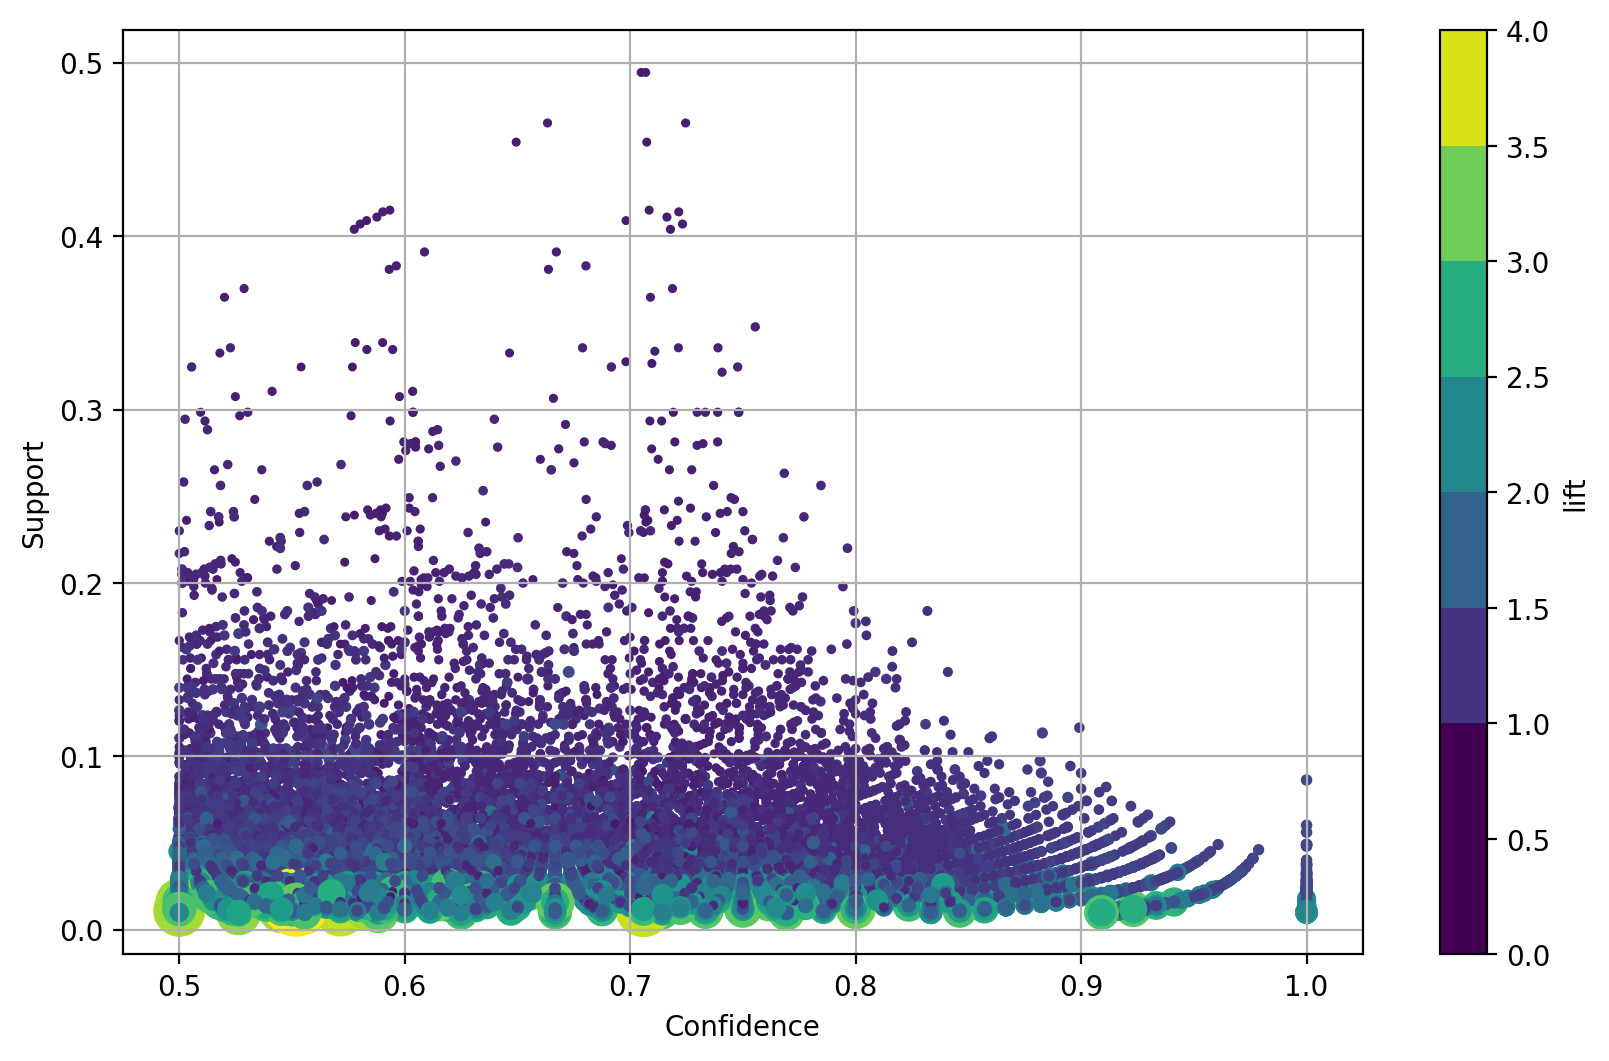

In [16]:
# Scatterplot of Support versus Confidence with Lift as color
plt.figure(figsize=(10,6), dpi = 200)
plt.scatter(assoc_rules['confidence'], assoc_rules['support'],
            c = assoc_rules['lift'], s = 5**assoc_rules['lift'])
plt.grid(True, axis = 'both')
plt.xlabel("Confidence")
plt.ylabel("Support")
plt.colorbar(boundaries = numpy.arange(0.0, 4.5, 0.5)).set_label('lift')
plt.show()

In [17]:
# Find the desired itemsets and association rules
frequent_itemsets = apriori(ItemIndicator, min_support = 0.1, max_len = 7, use_colnames = True)
assoc_rules = association_rules(frequent_itemsets, metric = "confidence", min_threshold = 0.8)

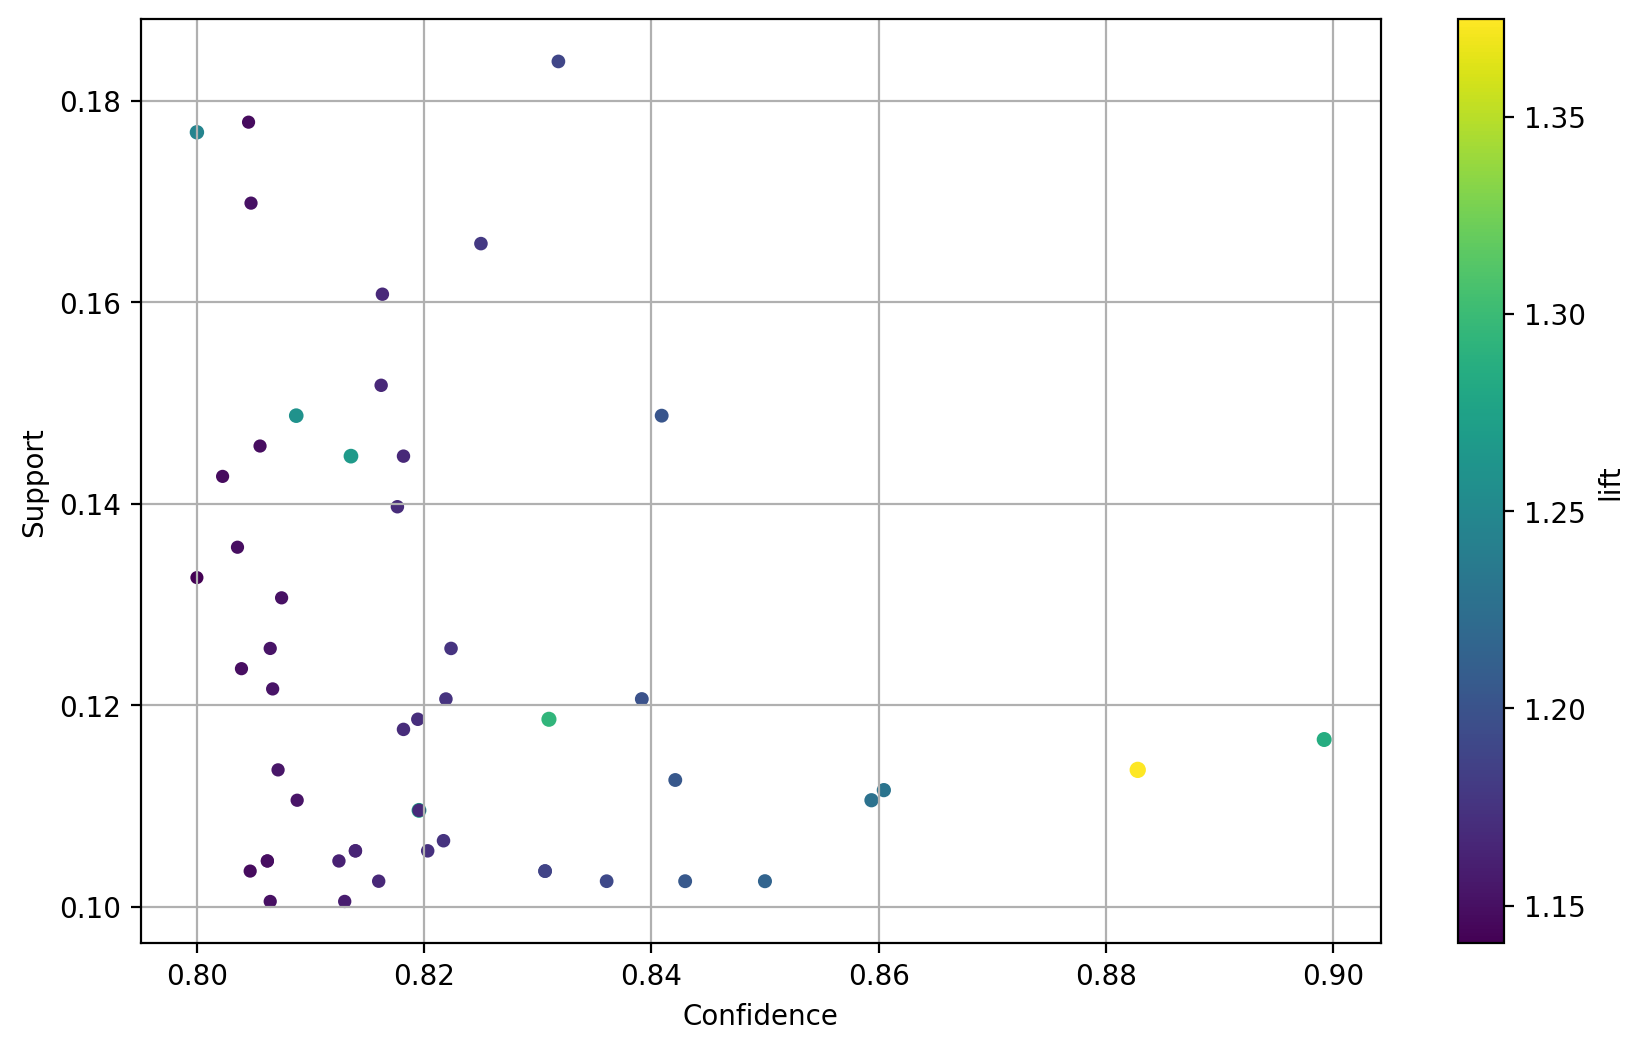

In [18]:
# Scatterplot of Support versus Confidence with Lift as color
plt.figure(figsize=(10,6), dpi = 200)
plt.scatter(assoc_rules['confidence'], assoc_rules['support'],
            c = assoc_rules['lift'], s = 10**assoc_rules['lift'])
plt.grid(True, axis = 'both')
plt.xlabel("Confidence")
plt.ylabel("Support")
plt.colorbar().set_label('lift')
plt.show()

In [20]:
# Show rules that have the 'CEREAL' consquent
Cereal_Consequent_Rule = assoc_rules[numpy.isin(assoc_rules["consequents"].values, {"Cereal"})]
Cereal_Consequent_Rule

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Oranges),(Cereal),0.221106,0.642211,0.176884,0.800000,1.245696,1.0,0.034888,1.788945,0.253226,0.257687,0.441011,0.537715
6,"(Bread, Oranges)",(Cereal),0.128643,0.642211,0.113568,0.882812,1.374645,1.0,0.030952,3.053132,0.312776,0.172783,0.672468,0.529826
9,"(Oranges, Buns)",(Cereal),0.133668,0.642211,0.109548,0.819549,1.276136,1.0,0.023704,1.982747,0.249771,0.164404,0.495649,0.495064
15,"(Oranges, Cheese)",(Cereal),0.183920,0.642211,0.148744,0.808743,1.259311,1.0,0.030629,1.870725,0.252322,0.219585,0.465448,0.520178
18,"(Oranges, Chips)",(Cereal),0.177889,0.642211,0.144724,0.813559,1.266810,1.0,0.030481,1.919050,0.256189,0.214286,0.478909,0.519456
37,"(Chips, Oranges, Cheese)",(Cereal),0.142714,0.642211,0.118593,0.830986,1.293945,1.0,0.026941,2.116918,0.264987,0.177979,0.527615,0.507825


In [21]:
# Show rules that have the 'Oranges' antecedent
antecedent = assoc_rules["antecedents"]
selectAntecedent = numpy.ones((assoc_rules.shape[0], 1), dtype=bool)

In [22]:
i = 0
for f in antecedent:
    selectAntecedent[i,0] = "Oranges" in f
    i = i + 1

In [25]:
Orange_Antecedent_Rule = assoc_rules[selectAntecedent]

Orange_Antecedent_Rule


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Oranges),(Cereal),0.221106,0.642211,0.176884,0.800000,1.245696,1.0,0.034888,1.788945,0.253226,0.257687,0.441011,0.537715
1,(Oranges),(Cheese),0.221106,0.699497,0.183920,0.831818,1.189165,1.0,0.029257,1.786772,0.204231,0.249659,0.440331,0.547375
3,(Oranges),(Chips),0.221106,0.701508,0.177889,0.804545,1.146881,1.0,0.022782,1.527171,0.164425,0.238866,0.345194,0.529064
6,"(Bread, Oranges)",(Cereal),0.128643,0.642211,0.113568,0.882812,1.374645,1.0,0.030952,3.053132,0.312776,0.172783,0.672468,0.529826
8,"(Bread, Oranges)",(Cheese),0.128643,0.699497,0.110553,0.859375,1.228561,1.0,0.020567,2.136907,0.213505,0.154062,0.532034,0.508710
9,"(Oranges, Buns)",(Cereal),0.133668,0.642211,0.109548,0.819549,1.276136,1.0,0.023704,1.982747,0.249771,0.164404,0.495649,0.495064
10,"(Oranges, Buns)",(Cheese),0.133668,0.699497,0.112563,0.842105,1.203872,1.0,0.019062,1.903183,0.195476,0.156206,0.474564,0.501512
12,"(Oranges, Buns)",(Chips),0.133668,0.701508,0.109548,0.819549,1.168268,1.0,0.015778,1.654146,0.166255,0.150970,0.395458,0.487855
14,"(Oranges, Cereal)",(Cheese),0.176884,0.699497,0.148744,0.840909,1.202162,1.0,0.025014,1.888873,0.204303,0.204420,0.470584,0.526776
15,"(Oranges, Cheese)",(Cereal),0.183920,0.642211,0.148744,0.808743,1.259311,1.0,0.030629,1.870725,0.252322,0.219585,0.465448,0.520178


In [19]:
# compute combinations 50 c 7
from math import comb
comb(50, 7)

99884400

In [22]:
# Find frequent itemsets with minimum support of 100 customers
min_customers = 100
min_support_100 = min_customers / nCustomer
print(f"Total number of customers: {nCustomer}")
print(f"Minimum support for 100 customers: {min_support_100:.4f}")

frequent_itemsets_100 = apriori(ItemIndicator, min_support=min_support_100, max_len=7, use_colnames=True)
print(f"\nNumber of Frequent Itemsets with at least 100 customers: {len(frequent_itemsets_100)}")
print("\nFrequent Itemsets:")
print(frequent_itemsets_100)

Total number of customers: 995
Minimum support for 100 customers: 0.1005

Number of Frequent Itemsets with at least 100 customers: 571

Frequent Itemsets:
      support                                           itemsets
0    0.701508                                     (BBQ Pork Bun)
1    0.642211                                   (Bean Paste Bun)
2    0.573869                             (Coconut Cocktail Bun)
3    0.469347                            (Coconut Sweet Top Bun)
4    0.129648                                     (Coconut Tart)
..        ...                                                ...
566  0.111558  (Ham & Egg Bun, Plain Dinner Rolls, Coconut Tw...
567  0.100503  (Ham & Egg Bun, Plain Dinner Rolls, BBQ Pork B...
568  0.104523  (Ham & Egg Bun, Plain Dinner Rolls, BBQ Pork B...
569  0.101508  (Ham & Egg Bun, Coconut Cocktail Bun, Bean Pas...
570  0.103518  (Ham & Egg Bun, Bean Paste Bun, Plain Dinner R...

[571 rows x 2 columns]


In [28]:
# compute max assocaition rules for 16 items
no_of_items = 16
max_rules = 3**no_of_items - 2**(no_of_items + 1) + 1
print(f"Maximum possible association rules for {no_of_items} items: {max_rules}")


Maximum possible association rules for 16 items: 42915650


In [31]:
# Calculate Leverage for the rule {Banana, Durian} => {Apple, Coconut, Eggplant}
# Given: Support({Apple, Banana, Coconut, Durian, Eggplant}) = 1

# If the complete 5-itemset has support = 1, then all subsets also have support = 1
support_union = 1.0  # Support(A ∪ C) = Support({Apple, Banana, Coconut, Durian, Eggplant})
support_antecedent = 1.0  # Support({Banana, Durian})
support_consequent = 1.0  # Support({Apple, Coconut, Eggplant})

# Leverage formula: Leverage = Support(A ∪ C) - Support(A) × Support(C)
leverage = support_union - (support_antecedent * support_consequent)

print("Rule: {Banana, Durian} => {Apple, Coconut, Eggplant}")
print(f"Support(A ∪ C) = {support_union}")
print(f"Support(Antecedent) = {support_antecedent}")
print(f"Support(Consequent) = {support_consequent}")
print(f"\nLeverage = {support_union} - ({support_antecedent} × {support_consequent})")
print(f"Leverage = {support_union} - {support_antecedent * support_consequent}")
print(f"Leverage = {leverage}")

Rule: {Banana, Durian} => {Apple, Coconut, Eggplant}
Support(A ∪ C) = 1.0
Support(Antecedent) = 1.0
Support(Consequent) = 1.0

Leverage = 1.0 - (1.0 × 1.0)
Leverage = 1.0 - 1.0
Leverage = 0.0
